In [1]:
from _setup import setup_project_root
PROJECT_ROOT = setup_project_root()

In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from models.lstm import build_lstm_sequences, get_lstm_model
import numpy as np
from evaluation.metrics import compute_metrics, compute_metrics_real_scale
import joblib
import tensorflow as tf

In [3]:
train_df = pd.read_csv(PROJECT_ROOT / "data" / "global_split" / "train.csv")
val_df   = pd.read_csv(PROJECT_ROOT / "data" / "global_split" / "val.csv")
test_df  = pd.read_csv(PROJECT_ROOT / "data" / "global_split" / "test.csv")

In [4]:
pm25_scaler = joblib.load(PROJECT_ROOT / "artifacts" / "pm25_scaler.pkl")

c:\Users\KimNgan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [5]:
train_df['PM2.5_scaled'] = pm25_scaler.fit_transform(train_df[['PM2.5']])
val_df['PM2.5_scaled']   = pm25_scaler.transform(val_df[['PM2.5']])
test_df['PM2.5_scaled']  = pm25_scaler.transform(test_df[['PM2.5']])

In [6]:
X_train, y_train, _ = build_lstm_sequences(train_df, 'PM2.5_scaled')
X_val, y_val, _     = build_lstm_sequences(val_df, 'PM2.5_scaled')
X_test, y_test, _   = build_lstm_sequences(test_df, 'PM2.5_scaled')

model = get_lstm_model(input_shape=(24, 1))
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train, 
    validation_data=(X_val, y_val),
    epochs=50, batch_size=64, callbacks=[early_stop]
)

Epoch 1/50
865/865 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - loss: 0.0250 - val_loss: 0.0210
Epoch 2/50
865/865 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - loss: 0.0204 - val_loss: 0.0210
Epoch 3/50
865/865 ━━━━━━━━━━━━━━━━━━━━ 27s 31ms/step - loss: 0.0201 - val_loss: 0.0202
Epoch 4/50
865/865 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - loss: 0.0200 - val_loss: 0.0201
Epoch 5/50
865/865 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - loss: 0.0199 - val_loss: 0.0199
Epoch 6/50
865/865 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - loss: 0.0199 - val_loss: 0.0199
Epoch 7/50
865/865 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - loss: 0.0198 - val_loss: 0.0200
Epoch 8/50
865/865 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - loss: 0.0198 - val_loss: 0.0198
Epoch 9/50
865/865 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - loss: 0.0198 - val_loss: 0.0203
Epoch 10/50
865/865 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - loss: 0.0197 - val_loss: 0.0200
Epoch 11/50
865/865 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - loss: 0.0196 - val_loss: 0.0201
Epoch 12/50
865/865 ━━━━━━━━━━

In [13]:
pred_test = model.predict(X_test)
pred_real = pm25_scaler.inverse_transform(pred_scaled)
y_real = pm25_scaler.inverse_transform(y_test)

res = compute_metrics(y_real, pred_real)
print("GLOBAL LSTM Metrics:", res)

209/209 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
GLOBAL LSTM Metrics: {'Correlation': 0.5465580849490598, 'RMSE': 0.1442706470650895, 'MAPE': 2533.202414883475, 'MAE': 0.09934437718708777}


In [14]:
metrics= compute_metrics_real_scale(
    y_test,      
    pred_test,   
    scaler=pm25_scaler
)
metrics

{'Correlation': 0.5465580849490598,
 'RMSE': 0.1442706470650895,
 'MAPE': 0.4942352479803348,
 'MAE': 0.09934437718708777}

In [15]:
metrics= compute_metrics_real_scale(
    y_test[:, 0],      
    pred_test[:, 0],   
    scaler=pm25_scaler
)
metrics

{'Correlation': 0.8972656023289767,
 'RMSE': 0.07544419650089931,
 'MAPE': 0.18662113717624118,
 'MAE': 0.048493380261067164}

In [16]:
%load_ext autoreload
%autoreload 2

from evaluation.plots import (
    plot_actual_vs_pred,
    plot_scatter_actual_pred,
    plot_residuals_vs_pred,
    plot_error_distribution,
    plot_actual_vs_pred_by_station,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


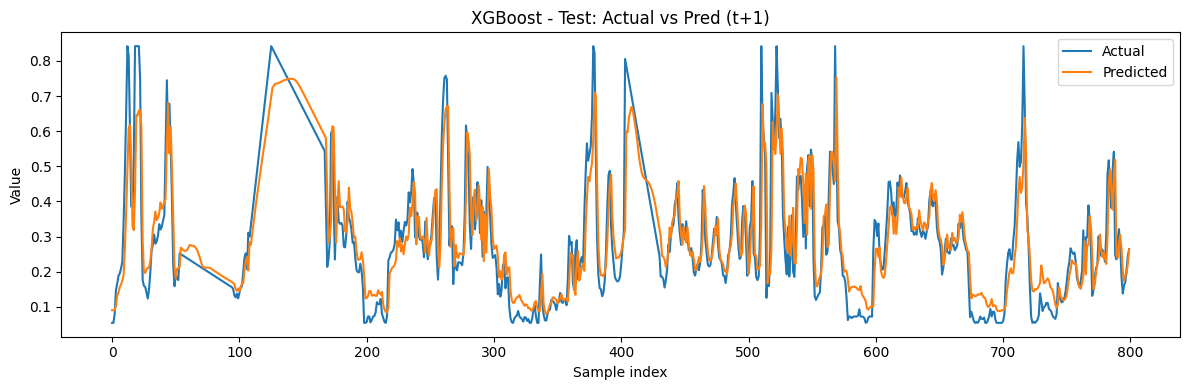

In [17]:
plot_actual_vs_pred(
    y_test, pred_test,
    title="XGBoost - Test: Actual vs Pred (t+1)",
    horizon=0,
    n_points=800
)

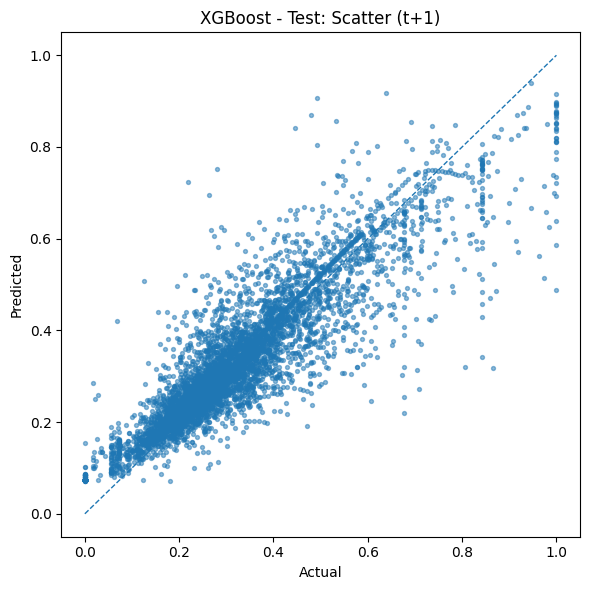

In [18]:
plot_scatter_actual_pred(
    y_test, pred_test,
    title="XGBoost - Test: Scatter (t+1)",
    horizon=0,
    sample=6000
)

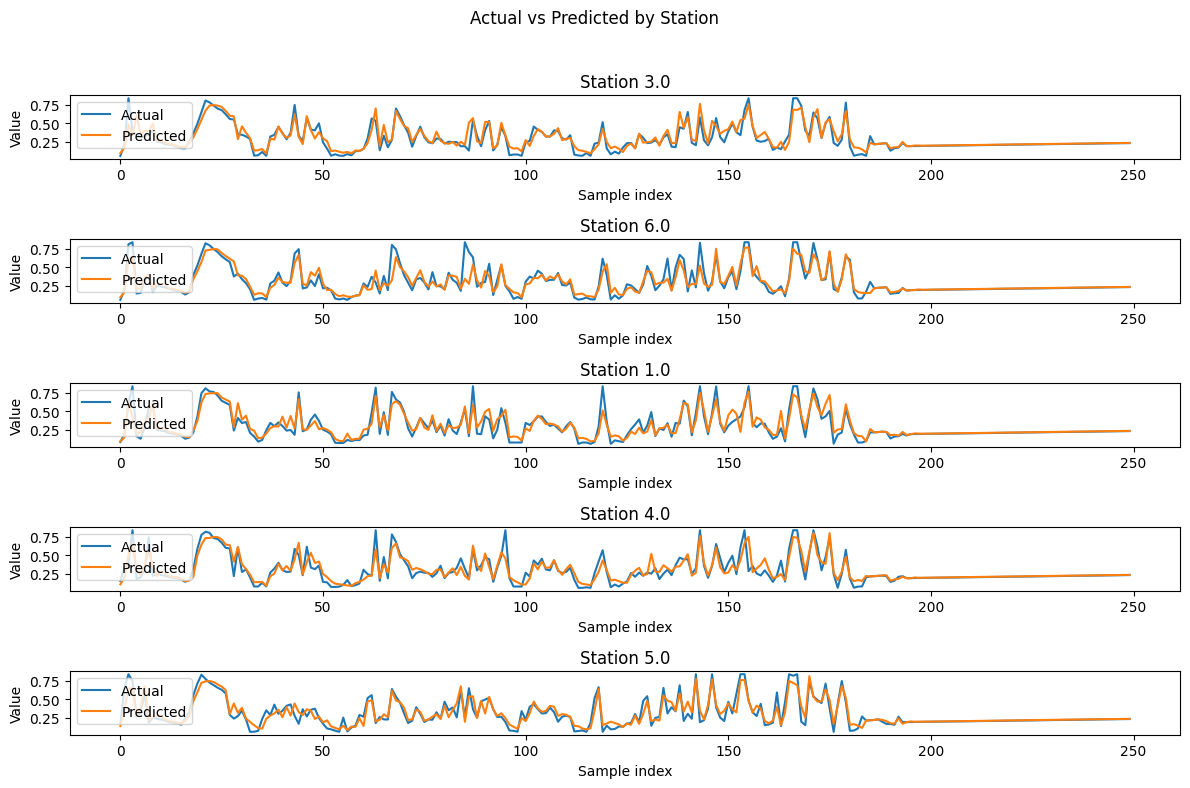

In [19]:
station_ids_aligned = test_df["Station_No"].values[-len(y_test):]

plot_actual_vs_pred_by_station(
    station_ids=station_ids_aligned,
    y_true=y_test,
    y_pred=pred_test,
    horizon=0,              
    n_points_per_station=250,
    max_stations=5
)